In [1]:
import scipy
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
import sys
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

from scipy import stats

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from spike_generator import generate_spikes

In [2]:
# load data
mat_lambda = scipy.io.loadmat(Path('../data') / 'lambda_slow-gain.mat')
rate = mat_lambda['lambda']
mat_tuning = scipy.io.loadmat(Path('../data') / 'tuning_slow-gain.mat')
tuning_curves = mat_tuning['tuning_curves']
mat_gain = scipy.io.loadmat(Path('../data') / 'gain_slow-gain.mat')
gain = mat_gain['gain']

mat2 = scipy.io.loadmat(Path('../data') / 'bin_sizes_all.mat')
bin_sizes_all = mat2['bin_sizes_all'][0]
ibin = -3

n_neurons = rate.shape[0]
n_trials = rate.shape[2]

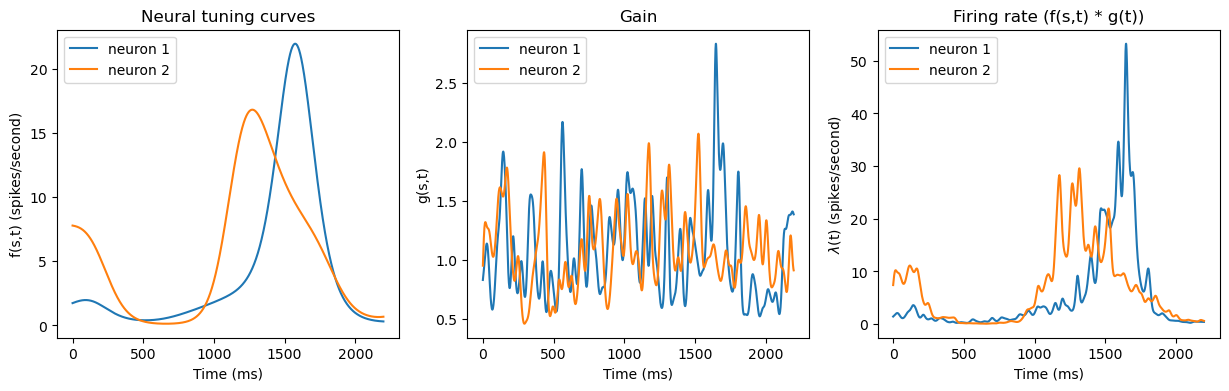

In [3]:
# pick two neurons only
neuron_idx = [12, 14]
# neuron_idx = np.arange(0, n_neurons)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(tuning_curves[neuron_idx, :, 0].T)
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('f(s,t) (spikes/second)')
axs[0].set_title('Neural tuning curves')
axs[0].legend(('neuron 1','neuron 2'))

axs[1].plot(gain[neuron_idx, :, 0].T)
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('g(s,t)')
axs[1].set_title('Gain')
axs[1].legend(('neuron 1','neuron 2'))

axs[2].plot(rate[neuron_idx, :, 0].T)
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel(r'$\lambda$(t) (spikes/second)')
axs[2].set_title('Firing rate (f(s,t) * g(t))')
axs[2].legend(('neuron 1','neuron 2'))

plt.show()

In [4]:
# simulate spikes
dt = 1e-3
spike_train = generate_spikes(rate[neuron_idx], dt) # create population response vectors

In [ ]:
# create population response vectors; the number of bins determine the number of representational locations
bin_length = int(bin_sizes_all[ibin] / dt)
n_bins = int(spike_train.shape[1] // bin_length)
spike_train_reshaped = np.reshape(spike_train, (len(neuron_idx), n_bins, bin_length, n_trials)) # n_neurons x n_bins x bin_length x n_trials
mean_spike_train = np.sum(spike_train_reshaped, axis=2) # n_neurons x n_bins x n_trials

In [6]:
# only use a single trial
X = mean_spike_train[:, :, 0].T
print(X.shape) # (n_samples x n_features)

y = np.arange(n_bins)
print(y.shape)

(4, 2)
(4,)


In [7]:
# train minimal classifier
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = SVC(decision_function_shape='ovo', kernel='linear')
clf.fit(X_scaled, y)

# predict and evaluate on same trial (sanity check)
y_pred = clf.predict(X_scaled)
print("One-vs-One Accuracy:", accuracy_score(y, y_pred))
print(clf.predict(X_scaled[0].reshape(1, -1))) # first bin
print(clf.predict(X_scaled[1].reshape(1, -1))) # second bin
print(clf.predict(X_scaled[2].reshape(1, -1))) # third bin
print(clf.predict(X_scaled[3].reshape(1, -1))) # forth bin
print('------------------------------')

# predict and evaluate on a hold-out trial 
print(clf.predict(scaler.transform(mean_spike_train[:, 0, 10].T.reshape(1, -1)))) # 11th trial, first bin
print(clf.predict(scaler.transform(mean_spike_train[:, 1, 10].T.reshape(1, -1)))) # 11th trial, second bin
print(clf.predict(scaler.transform(mean_spike_train[:, 2, 10].T.reshape(1, -1)))) # 11th trial, third bin
print(clf.predict(scaler.transform(mean_spike_train[:, 3, 10].T.reshape(1, -1)))) # 11th trial, fourth bin

One-vs-One Accuracy: 1.0
[0]
[1]
[2]
[3]
------------------------------
[2]
[1]
[0]
[2]


In [8]:
# plot decision boundary!

In [29]:
# use two trials
trial_idx = [0, 5]

X2 = mean_spike_train[:, :, trial_idx].transpose(1, 2, 0) # n_bins x n_trials x n_neurons
print(X2.shape)
print('-------')
print(X)
print('--------')
print(X2)
X2_train = X2.reshape(-1, len(neuron_idx)) # n_samples x n_features
print('------------------')
print(X2_train.shape)
print('--------')
print(X2_train) 

(4, 2, 2)
-------
[[5 3]
 [4 1]
 [2 4]
 [0 3]]
--------
[[[5 3]
  [0 4]]

 [[4 1]
  [2 3]]

 [[2 4]
  [5 2]]

 [[0 3]
  [3 2]]]
------------------
(8, 2)
--------
[[5 3]
 [0 4]
 [4 1]
 [2 3]
 [2 4]
 [5 2]
 [0 3]
 [3 2]]


In [30]:
y2 = np.repeat(np.arange(n_bins), len(trial_idx))
print(y2.shape)
print('----------')
print(y2)

(8,)
----------
[0 0 1 1 2 2 3 3]


In [31]:
# train classifier on two trials
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2_train)

clf2 = SVC(decision_function_shape='ovo', kernel='linear')
clf2.fit(X2_scaled, y2)

# predict and evaluate on same trial (sanity check)
y2_pred = clf2.predict(X2_scaled)
print("One-vs-One Accuracy:", accuracy_score(y2, y2_pred))

One-vs-One Accuracy: 0.5


In [12]:
# plot decision boundary!